# Notebook 06 - Monotone-architecture neural survival model

The arm this project exists to test.

Notebook 04 asked a network for the cumulative hazard and then paid a penalty to
discourage it from going down. This notebook removes the need for the penalty by
changing what the network is asked for. The head outputs the **instantaneous
hazard**:

$$\lambda(x, t) = \mathrm{softplus}\big(f_\theta([x, t])\big) \;>\; 0$$

and the cumulative hazard is obtained by integrating it:

$$\Lambda(x, t) = \int_0^{t} \lambda(x, s)\,ds$$

Because the integrand is strictly positive for every input and every parameter
value, $\Lambda$ is non-decreasing in $t$ as a matter of arithmetic, and
$S(t) = e^{-\Lambda(t)}$ is non-increasing. Not encouraged. Not penalised.
Not approximately. The integral of a positive function cannot decrease.

**No penalty term.** There is no collocation grid, no $\alpha$ to choose, and
nothing to trade against the likelihood. The residual $\mathrm{relu}(-d\Lambda/dt)^2$
is still computed once at the end, purely as a diagnostic, and it should come
back exactly zero. If it does not, the integration is wrong.

Unlike Cox (notebook 05), nothing here forces the hazard ratio between two
borrowers to stay constant over time: $\lambda$ depends on $x$ and $t$ jointly,
so a covariate's effect is free to change shape as the loan seasons. This arm is
the one that is both structurally valid and free of the proportional hazards
assumption, which is why it is the interesting cell of the table.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.common import (load_data, make_split, build_features, describe_split,
                        survival_arrays, subsample_train, horizon_labels,
                        HORIZONS, SEED, SUBSAMPLE_N, RESULTS_DIR)
from src.evaluate import evaluate_arm, save_arm_results, plot_calibration
from src.monotonicity import audit_monotonicity, format_audit
from src.torch_arms import set_seed, as_tensors, train_minibatch, plot_history
from src.report import build_master_table, format_master, missing_arms, plot_cost_of_structure

set_seed(SEED)
RESULTS_DIR.mkdir(exist_ok=True)
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1+cpu | threads 8


## The shared protocol

Same split, same features, same 300,000-row stratified training subsample as the
other survival arms. Test untouched at 674,272 rows.

In [2]:
df = load_data()
train_df_full, test_df = make_split(seed=SEED)
train_df = subsample_train(train_df_full, n=SUBSAMPLE_N)

print(f"full train rows      : {len(train_df_full):,}")
print(f"subsampled train rows: {len(train_df):,}  "
      f"(event rate {train_df['event'].mean():.6f})")
print(f"test rows            : {len(test_df):,}  (not subsampled)")
print()

feat = build_features(train_df, test_df)
t_tr, e_tr = survival_arrays(train_df)
t_te, e_te = survival_arrays(test_df)

print(describe_split(train_df, test_df).to_string(index=False))
print()
print("design matrix:", feat.X_train.shape, feat.X_test.shape)
print("features:", feat.names)

X_tr, T_tr, E_tr = as_tensors(feat.X_train, t_tr, e_tr)

full train rows      : 1,573,299
subsampled train rows: 300,000  (event rate 0.128023)
test rows            : 674,272  (not subsampled)



split   rows  event_rate  median_time_m
train 300000    0.128023           17.3
 test 674272    0.127732           18.2

design matrix: (300000, 14) (674272, 14)
features: ['annual_inc', 'dti', 'loan_amnt', 'int_rate', 'term', 'grade', 'emp_length_missing', 'emp_length', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']


## Model

The head is a plain MLP whose output passes through a Softplus, giving the
hazard. Two integrals are needed and they are done differently for good reason.

**During training** the upper limit is a different $t_i$ for every row, so the
quadrature is rescaled per row: fixed nodes $u_k \in [0, 1]$ are mapped to
$s_k = t_i u_k$ and the trapezoid rule is applied over the actual times. That
gives $\Lambda(x_i, t_i)$ at each row's own observed time, exactly where the
likelihood needs it.

**At prediction time** the same fine grid serves every requested time, so the
hazard is evaluated once on a 0-to-60 month grid at 0.25-month steps and the
cumulative trapezoid is taken along it, then interpolated. Both the cumulative
sum and the linear interpolation preserve non-negativity of the increments, so
the monotonicity guarantee survives the numerics.

In [3]:
TIME_SCALE = 60.0
N_QUAD = 32          # quadrature nodes per row during training
FINE_STEP = 0.25     # prediction grid resolution in months

# Marginal hazard implied by the training data: events divided by total exposure.
# Used only to initialise the output bias at a sensible scale.
BASE_HAZARD = float(e_tr.sum() / t_tr.sum())
print(f"marginal hazard in train: {BASE_HAZARD:.6f} defaults per month-at-risk")


class MonotoneHazardNN(nn.Module):
    """
    lambda(x, t) = softplus(net([x, t])) > 0 by construction.

    Lambda(x, t) = integral of lambda from 0 to t, so dLambda/dt = lambda >= 0
    holds structurally: it is the integral of a positive function. S = exp(-Lambda)
    is therefore non-increasing for every borrower, with no penalty term.
    """

    def __init__(self, d, hidden=64, base_hazard=BASE_HAZARD):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        # Start the hazard head at the marginal hazard rather than at
        # softplus(0) ~ 0.69 defaults per month, which is about a hundred times
        # the real rate and makes the first epochs a long walk back down.
        # Inverse softplus: b = log(exp(h) - 1).
        with torch.no_grad():
            self.net[-1].bias.fill_(float(np.log(np.expm1(base_hazard))))
            self.net[-1].weight.mul_(0.1)

    def hazard(self, x, t):
        """Instantaneous hazard, strictly positive."""
        return F.softplus(self.net(torch.cat([x, t / TIME_SCALE], dim=1)))

    def cumhaz(self, x, t, n_nodes=N_QUAD):
        """Lambda(x, t) by per-row rescaled trapezoid on [0, t]."""
        n, d = x.shape
        u = torch.linspace(0.0, 1.0, n_nodes, device=x.device)      # (K,)
        s = t * u.view(1, -1)                                        # (n, K)
        xr = x.unsqueeze(1).expand(n, n_nodes, d).reshape(-1, d)
        lam = self.hazard(xr, s.reshape(-1, 1)).view(n, n_nodes)
        return torch.trapezoid(lam, s, dim=1).view(-1, 1)


model = MonotoneHazardNN(X_tr.shape[1])
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

marginal hazard in train: 0.006444 defaults per month-at-risk
MonotoneHazardNN(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
parameters: 5249


## Loss

The same right-censored survival negative log-likelihood used by the corrected
notebook 04:

$$-\ell = -\frac{1}{N}\sum_i\Big[\delta_i \log\lambda(x_i, t_i) - \Lambda(x_i, t_i)\Big]$$

with $\lambda_i$ read straight off the hazard head at $t_i$ and $\Lambda_i$ from
the quadrature above.

Note what is missing relative to notebook 04. There is no penalty term. There is
also no clamp inside the logarithm: notebook 04 needed `lam.clamp_min(1e-8)`
because its autograd hazard could go negative and produce a NaN. Here the hazard
is a Softplus output and cannot be negative, so the only guard is a small epsilon
against float32 underflow.

In [4]:
def step_loss(model, xb, tb, eb, eps=1e-8):
    lam = model.hazard(xb, tb)          # > 0 by construction, no clamp needed
    Lam = model.cumhaz(xb, tb)
    nll = -eb * torch.log(lam + eps) + Lam
    loss = nll.mean()
    return loss, {"data": float(loss.detach())}

## Training

Same routine as the other neural arms: minibatch Adam, a validation slice held
out of train, early stopping with best-weight restoration.

The batch is 4096 rather than 8192 because each row costs 32 hazard evaluations
for its quadrature, so a step touches roughly 131,000 forward rows either way.

The epoch cap is 60 rather than 40. The cap is not a tuning knob and is not
there to help this arm: what matters is that **early stopping, not the cap,**
decides when training ends, otherwise a reported metric measures a truncated
optimisation rather than the model. The stopping epoch is printed below, and if
it equals the cap the arm is undertrained and the number should not be read as
the cost of monotonicity.

In [5]:
set_seed(SEED)
model = MonotoneHazardNN(X_tr.shape[1])

history = train_minibatch(model, step_loss, X_tr, T_tr, E_tr,
                          batch_size=4096, max_epochs=60, lr=1e-3,
                          val_frac=0.1, patience=5, seed=SEED, monitor="data")

train rows 270,000 | val rows 30,000 | batch 4096 | 66 steps/epoch


epoch   1 | train 0.75770 | val 0.73189 | data=0.73189 | * (14s)


epoch   2 | train 0.75029 | val 0.72953 | data=0.72953 | * (29s)


epoch   3 | train 0.74888 | val 0.72889 | data=0.72889 | * (45s)


epoch   4 | train 0.74836 | val 0.72830 | data=0.72830 | * (62s)


...

epoch  31 | train 0.73901 | val 0.72009 | data=0.72009 |   (444s)


epoch  32 | train 0.73907 | val 0.72018 | data=0.72018 |   (458s)


epoch  33 | train 0.73905 | val 0.72044 | data=0.72044 |   (473s)


epoch  34 | train 0.73898 | val 0.72021 | data=0.72021 |   (497s)


epoch  35 | train 0.73898 | val 0.72029 | data=0.72029 |   (514s)
early stop at epoch 35; best epoch 30 (data=0.72019)
restored weights from epoch 30 | 2310 gradient steps in 514s
early stopping fired (min_delta=0.0001); the 60-epoch cap did not bind


 epoch  train_total  val_total  steps   seconds
     1      0.75770    0.73189     66  14.47036
     2      0.75029    0.72953    132  29.22245
     3      0.74888    0.72889    198  45.10332
     4      0.74836    0.72830    264  61.87795
     5      0.74806    0.72822    330  78.66783
     6      0.74759    0.72781    396  94.23399
     7      0.74716    0.72724    462 109.54043
     8      0.74681    0.72681    528 125.21980
     9      0.74643    0.72638    594 140.18217
    10      0.74600    0.72576    660 154.63177
    11      0.74532    0.72540    726 169.54133
    12      0.74433    0.72387    792 184.49967
    13      0.74317    0.72285    858 198.65467
    14      0.74212    0.72201    924 212.31984
    15      0.74131    0.72199    990 225.66970
    16      0.74083    0.72141   1056 240.44886
    17      0.74049    0.72090   1122 254.01114
    18      0.74039    0.72087   1188 267.60949
    19      0.74007    0.72100   1254 281.02688
    20      0.73991    0.72084   1320 29

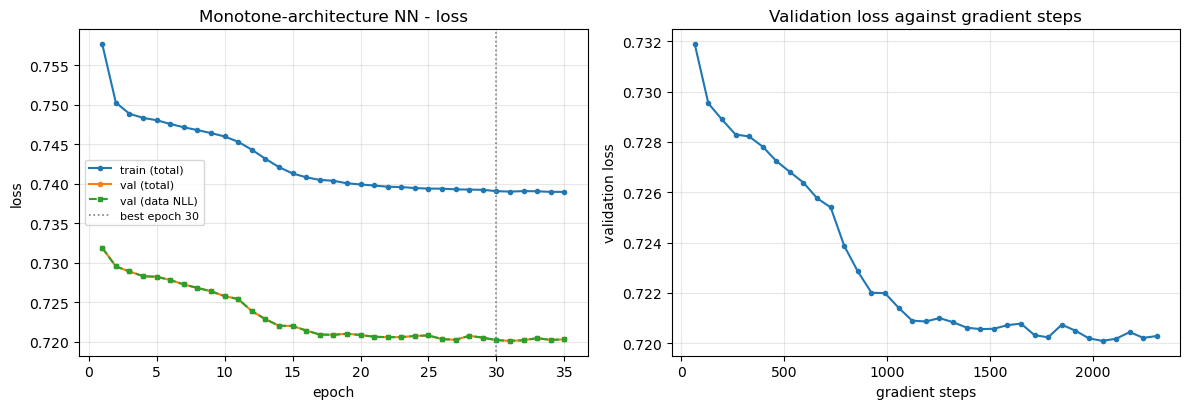

In [6]:
hist_df = pd.DataFrame({k: v for k, v in history.items() if isinstance(v, list)})
hist_df.to_csv(RESULTS_DIR / "nb06_training_history.csv", index=False)
print(hist_df[["epoch", "train_total", "val_total", "steps", "seconds"]]
      .round(5).to_string(index=False))
print()
print(f"stopped early: {history['stopped_early']}  "
      f"(False means the epoch ceiling bound and the arm is undertrained)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_history(history, title="Monotone-architecture NN - loss", ax=axes[0])
axes[1].plot(hist_df["steps"], hist_df["val_total"], "o-", ms=3)
axes[1].set_xlabel("gradient steps"); axes[1].set_ylabel("validation loss")
axes[1].set_title("Validation loss against gradient steps"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Prediction

The hazard is evaluated once on a fine grid, the cumulative trapezoid is taken
along it, and the result is interpolated to whatever times are asked for. Rows
are processed in chunks so the full test set never materialises at once.

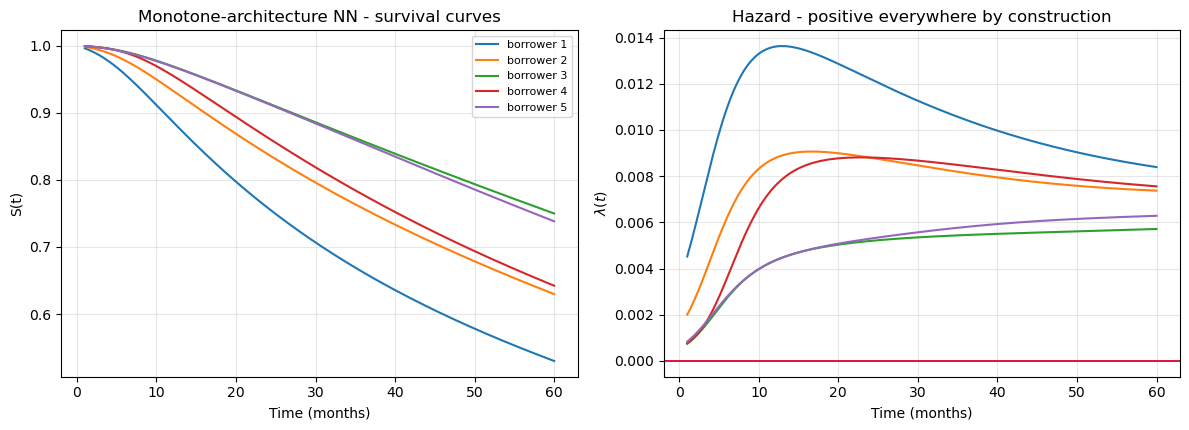

minimum hazard over the plotted grid: 0.0007423136266879737
largest increase in S between adjacent grid points: -0.00023312932426255983


In [7]:
def _fine_grid(times, step=FINE_STEP):
    return np.arange(0.0, float(np.max(times)) + step, step)


def _cumhaz_block(mdl, Xb, s):
    """Lambda on the fine grid for one block of rows."""
    n = len(Xb)
    xt = torch.as_tensor(Xb)
    lam = np.empty((n, len(s)), dtype=np.float64)
    with torch.no_grad():
        for k, sv in enumerate(s):
            tv = torch.full((n, 1), float(sv))
            lam[:, k] = mdl.hazard(xt, tv).numpy().ravel()
    d = np.diff(s)                                    # positive spacings
    avg = 0.5 * (lam[:, 1:] + lam[:, :-1])            # non-negative
    inc = avg * d                                     # non-negative increments
    return np.concatenate([np.zeros((n, 1)), np.cumsum(inc, axis=1)], axis=1)


def make_predictors(mdl, block=25_000):
    def predict_cumhaz(X, times):
        times = np.atleast_1d(np.asarray(times, float))
        X = np.asarray(X, np.float32)
        s = _fine_grid(times)
        out = np.empty((len(X), len(times)))
        for a in range(0, len(X), block):
            Lam = _cumhaz_block(mdl, X[a:a + block], s)
            for i in range(Lam.shape[0]):
                out[a + i] = np.interp(times, s, Lam[i])
        return out

    def predict_survival(X, times):
        return np.exp(-predict_cumhaz(X, times))

    return predict_survival, predict_cumhaz


predict_survival, predict_cumhaz = make_predictors(model)

grid = np.linspace(1, 60, 200)
Sc = predict_survival(feat.X_test[:5], grid)
lam5 = np.column_stack([
    model.hazard(torch.as_tensor(feat.X_test[:5]),
                 torch.full((5, 1), float(g))).detach().numpy().ravel()
    for g in grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for i in range(5):
    axes[0].plot(grid, Sc[i], lw=1.5, label=f"borrower {i + 1}")
    axes[1].plot(grid, lam5[i], lw=1.5)
axes[0].set_xlabel("Time (months)"); axes[0].set_ylabel("S(t)")
axes[0].set_title("Monotone-architecture NN - survival curves")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].axhline(0, color="crimson", lw=1.4)
axes[1].set_xlabel("Time (months)"); axes[1].set_ylabel(r"$\lambda(t)$")
axes[1].set_title("Hazard - positive everywhere by construction")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("minimum hazard over the plotted grid:", float(lam5.min()))
print("largest increase in S between adjacent grid points:",
      float(np.diff(Sc, axis=1).max()))

## Monotonicity audit and the zero-residual diagnostic

The audit runs identically to every other arm. The residual term that notebook 04
carried in its loss is computed here once, on the audit grid, purely as a check:
it should be exactly zero, and any non-zero value would mean the integration is
wrong rather than that the model is badly fitted.

In [8]:
mono = audit_monotonicity(predict_cumhaz, feat.X_test,
                          name="Monotone-architecture NN", n_borrowers=1000)
print(format_audit(pd.DataFrame([mono])).T.to_string(header=False))
print()

# Diagnostic only: relu(-dLambda/dt)^2 on the audit grid. Not part of any loss.
from src.common import MONO_GRID
rng = np.random.default_rng(SEED)
idx = rng.choice(len(feat.X_test), 1000, replace=False)
Lam = predict_cumhaz(feat.X_test[idx], MONO_GRID)
deriv = np.diff(Lam, axis=1) / np.diff(MONO_GRID)[None, :]
residual = float(np.mean(np.maximum(-deriv, 0.0) ** 2))

print(f"diagnostic residual mean[relu(-dLambda/dt)^2] = {residual:.3e}")
print(f"most negative dLambda/dt anywhere on the grid = {float(deriv.min()):.6e}")
if residual == 0.0:
    print("Exactly zero, as the architecture requires. No penalty term is used.")
else:
    print("NON-ZERO: the integration is wrong, not the fit.")

arm                      Monotone-architecture NN
n_borrowers                                  1000
n_grid_points                                 119
pct_points_violating                          0.0
pct_borrowers_violating                       0.0
max_violation_dLam_dt                         0.0
max_violation_dLam                            0.0
max_survival_increase                         0.0

diagnostic residual mean[relu(-dLambda/dt)^2] = 0.000e+00
most negative dLambda/dt anywhere on the grid = 1.378870e-04
Exactly zero, as the architecture requires. No penalty term is used.


## Evaluation

In [9]:
result = evaluate_arm(predict_survival, feat.X_test, test_df, train_df,
                     name="Monotone-architecture NN")
print(result)
print()
print("notes:", result.notes)

save_arm_results(result, mono, extra={
    "penalty": "none - monotonicity is structural",
    "diagnostic_residual": residual,
    "n_quad_nodes": N_QUAD,
    "fine_step_months": FINE_STEP,
    "best_epoch": history["best_epoch"],
    "total_steps": history["total_steps"],
    "stopped_early": history["stopped_early"],
    "epochs_run": history["epoch"][-1],
    "max_epochs": history["max_epochs"],
    "subsample_n": SUBSAMPLE_N,
    "n_train_used": int(len(train_df)),
})

EvalResult(Monotone-architecture NN)
                     arm  auc_12m  auc_24m  auc_36m  pct_borrowers_any_PD_inversion  largest_PD_reversal  pct_borrowers_PD12_gt_PD24  pct_borrowers_PD24_gt_PD36  c_harrell   c_uno  ibs_1_60m
Monotone-architecture NN 0.703792 0.691996 0.687116                             0.0                  0.0                         0.0                         0.0   0.688271 0.64816   0.142882

notes: {'n_test': 674272, 'n_train': 300000, 'backends': {'lifelines': True, 'scikit-survival': False}, 'c_index_n': 25000, 'ibs_n': 100000}


WindowsPath('C:/Users/arora/Downloads/credit_survival_project-main (2)/results/monotone_architecture_nn.json')

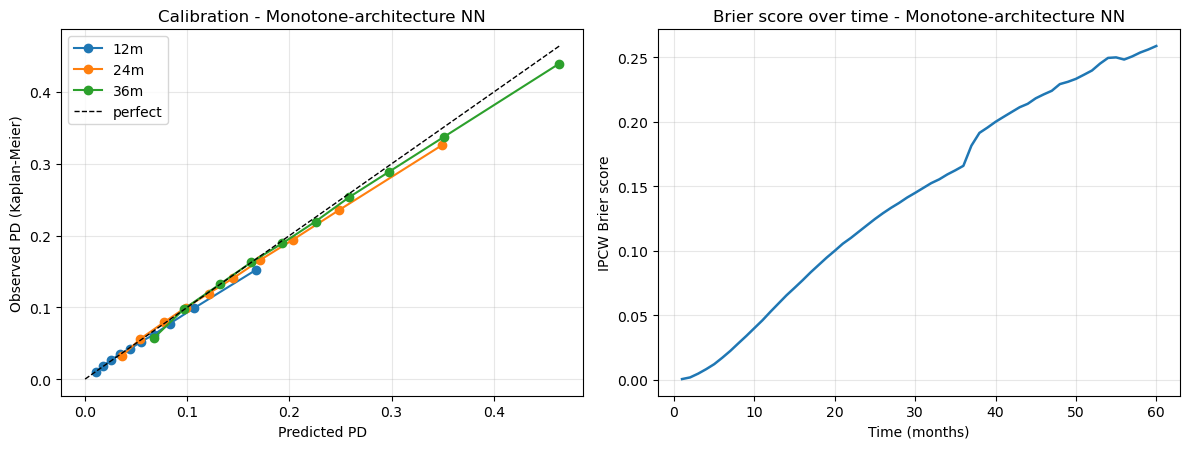

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_calibration(result, ax=axes[0])
axes[1].plot(result.brier["month"], result.brier["brier"], lw=1.8)
axes[1].set_xlabel("Time (months)"); axes[1].set_ylabel("IPCW Brier score")
axes[1].set_title("Brier score over time - Monotone-architecture NN")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## The `int_rate` ablation

`int_rate` is not an independent observation about the borrower. It is Lending
Club's own risk assessment, written down as a number: the grading committee read
the application and priced it. `grade` is the same judgement on a letter scale.
A model that scores well using them is partly re-deriving Lending Club's
underwriting rather than predicting default from borrower characteristics.

That distinction matters for what the AUCs in this study mean. Below, XGBoost
and the monotone network are each fitted twice on the same rows -- once with
`int_rate` and `grade`, once with both removed -- and the gap is the share of
measured discrimination that comes from the lender's own prior opinion.

Both models are fitted on the same 300,000-row subsample here, so the two halves
of each comparison differ only in the feature set. The XGBoost numbers in this
section are therefore not identical to notebook 02's, which used the full
training set; it is the **delta** that is the result, not the level.

In [11]:
DROP = ["int_rate", "grade"]
keep = [i for i, n in enumerate(feat.names) if n not in DROP]
print("full feature set   :", feat.names)
print("ablated feature set:", [feat.names[i] for i in keep])
print()

y_train = horizon_labels(train_df)
y_test = horizon_labels(test_df)

def xgb_aucs(Xtr, Xte, tag):
    out = {}
    for H in HORIZONS:
        m = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric="logloss", random_state=SEED,
                          tree_method="hist", n_jobs=-1)
        m.fit(Xtr, y_train[H])
        out[H] = roc_auc_score(y_test[H], m.predict_proba(Xte)[:, 1])
        print(f"  XGBoost {tag:<8} AUC @ {H:>2}m: {out[H]:.4f}")
    return out

print("XGBoost, both feature sets:")
xgb_with = xgb_aucs(feat.X_train, feat.X_test, "with")
xgb_without = xgb_aucs(feat.X_train[:, keep], feat.X_test[:, keep], "without")

full feature set   : ['annual_inc', 'dti', 'loan_amnt', 'int_rate', 'term', 'grade', 'emp_length_missing', 'emp_length', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']
ablated feature set: ['annual_inc', 'dti', 'loan_amnt', 'term', 'emp_length_missing', 'emp_length', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']

XGBoost, both feature sets:


  XGBoost with     AUC @ 12m: 0.7108


  XGBoost with     AUC @ 24m: 0.7082


  XGBoost with     AUC @ 36m: 0.7114


  XGBoost without  AUC @ 12m: 0.6120


  XGBoost without  AUC @ 24m: 0.6143


  XGBoost without  AUC @ 36m: 0.6205


In [12]:
def fit_monotone(Xtr, tag):
    set_seed(SEED)
    Xt, Tt, Et = as_tensors(Xtr, t_tr, e_tr)
    m = MonotoneHazardNN(Xt.shape[1])
    h = train_minibatch(m, step_loss, Xt, Tt, Et, batch_size=4096,
                        max_epochs=60, lr=1e-3, val_frac=0.1, patience=5,
                        seed=SEED, monitor="data", verbose=False)
    print(f"  monotone NN {tag}: best epoch {h['best_epoch']}, "
          f"{h['total_steps']} steps, val NLL {h['best_monitor']:.5f}")
    return m

def monotone_aucs(mdl, Xte, tag):
    ps, _ = make_predictors(mdl)
    S = ps(Xte, np.asarray(HORIZONS, float))
    out = {}
    for k, H in enumerate(HORIZONS):
        out[H] = roc_auc_score(y_test[H], 1.0 - S[:, k])
        print(f"  monotone NN {tag:<8} AUC @ {H:>2}m: {out[H]:.4f}")
    return out

print("Monotone-architecture NN, both feature sets:")
mono_with = monotone_aucs(model, feat.X_test, "with")
model_ab = fit_monotone(feat.X_train[:, keep], "without")
mono_without = monotone_aucs(model_ab, feat.X_test[:, keep], "without")

Monotone-architecture NN, both feature sets:


  monotone NN with     AUC @ 12m: 0.7038
  monotone NN with     AUC @ 24m: 0.6920


  monotone NN with     AUC @ 36m: 0.6871


  monotone NN without: best epoch 26, 2046 steps, val NLL 0.73725


  monotone NN without  AUC @ 12m: 0.6068
  monotone NN without  AUC @ 24m: 0.6044


  monotone NN without  AUC @ 36m: 0.6068


In [13]:
rows = []
for name, w, wo in (("XGBoost (independent horizons)", xgb_with, xgb_without),
                    ("Monotone-architecture NN", mono_with, mono_without)):
    for H in HORIZONS:
        rows.append({"model": name, "horizon_m": H,
                     "auc_with_int_rate_grade": w[H],
                     "auc_without_int_rate_grade": wo[H],
                     "delta": w[H] - wo[H]})

abl = pd.DataFrame(rows)
abl.to_csv(RESULTS_DIR / "int_rate_ablation.csv", index=False)
print(abl.round(4).to_string(index=False))
print()
print("mean AUC lost by removing int_rate and grade:")
print(abl.groupby("model")["delta"].mean().round(4).to_string())

                         model  horizon_m  auc_with_int_rate_grade  auc_without_int_rate_grade  delta
XGBoost (independent horizons)         12                   0.7108                      0.6120 0.0988
XGBoost (independent horizons)         24                   0.7082                      0.6143 0.0939
XGBoost (independent horizons)         36                   0.7114                      0.6205 0.0909
      Monotone-architecture NN         12                   0.7038                      0.6068 0.0970
      Monotone-architecture NN         24                   0.6920                      0.6044 0.0876
      Monotone-architecture NN         36                   0.6871                      0.6068 0.0804

mean AUC lost by removing int_rate and grade:
model
Monotone-architecture NN          0.0883
XGBoost (independent horizons)    0.0945


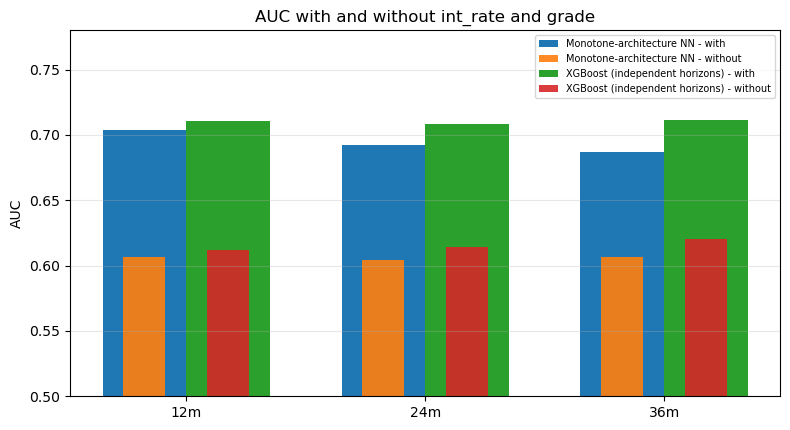

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.4))
w = 0.35
for j, (name, g) in enumerate(abl.groupby("model")):
    pos = np.arange(len(HORIZONS)) + (j - 0.5) * w
    ax.bar(pos, g["auc_with_int_rate_grade"], w, label=f"{name} - with")
    ax.bar(pos, g["auc_without_int_rate_grade"], w * 0.5,
           label=f"{name} - without", alpha=0.9)
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f"{H}m" for H in HORIZONS])
ax.set_ylabel("AUC"); ax.set_ylim(0.5, 0.78)
ax.set_title("AUC with and without int_rate and grade")
ax.legend(fontsize=7); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Master comparison

Every arm has now written `results/<arm>.json`. The table below is generated by
reading those files, never by transcribing a number, so a figure here can always
be traced to the notebook run that produced it and a stale arm shows up as a
missing row rather than as a plausible-looking stale value.

In [15]:
master = build_master_table()
missing = missing_arms(master)

print("MASTER COMPARISON")
print(format_master(master).to_string(index=False))
print()
if missing:
    print("MISSING ARMS (no results file):", missing)
else:
    print("All six arms present.")
print()
print("written to results/master_comparison.csv")

MASTER COMPARISON
                            arm  auc_12m  auc_24m  auc_36m  c_harrell  c_uno  ibs_1_60m  pct_points_violating  pct_borrowers_violating  max_survival_increase  pct_borrowers_any_PD_inversion   n_train  n_test
Logistic (independent horizons)   0.7012   0.6911   0.6876     0.6804 0.6419     0.1501                 0.000                      0.0               0.000000                           0.046 1,573,299 674,272
 XGBoost (independent horizons)   0.7121   0.7085   0.7117     0.6865 0.6523     0.1478                 0.183                      0.9               0.000427                           1.687 1,573,299 674,272
                         Cox PH   0.6987   0.6879   0.6838     0.6838 0.6438     0.1434                 0.000                      0.0               0.000000                           0.000   300,000 674,272
               Unconstrained NN   0.6879   0.6786   0.6388     0.6598 0.6362     0.1819                72.810                    100.0               0

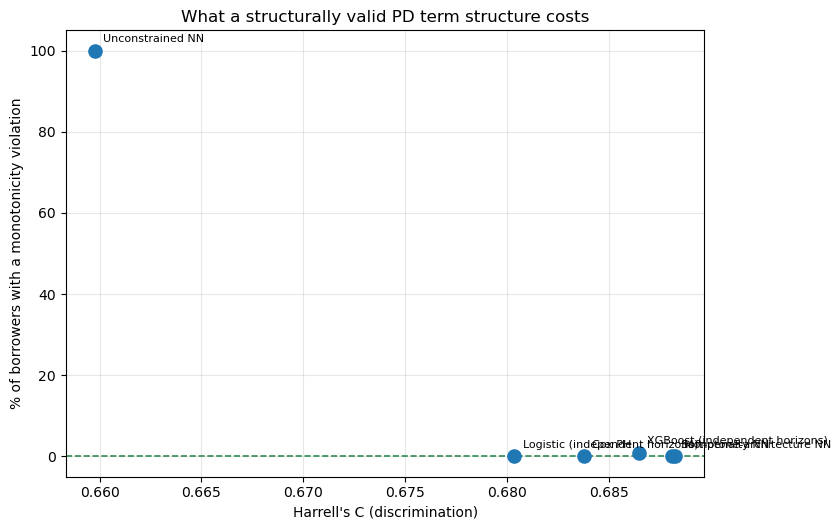

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.4))
plot_cost_of_structure(master, ax=ax)
plt.tight_layout(); plt.show()

## Summary

The comparison is now complete on identical held-out data. Read the table in two
columns: `c_harrell` for what an arm is worth as a ranking model, and
`pct_borrowers_violating` for how often it emits a term structure that cannot
occur.

Three arms achieve exactly zero violations, and they get there in different
ways. Cox does it by factorising the hazard, at the cost of assuming a
borrower's relative risk never changes over the life of the loan -- an
assumption the test in notebook 05 evaluates rather than asserts. The monotone
architecture does it by integrating a positive hazard, which costs no assumption
about the shape of covariate effects at all. The soft penalty does not guarantee
it; whatever its audit row says is what a penalty bought.

**Caveats that belong with these numbers.**

The `int_rate` ablation above says how much of the measured AUC is the model
re-learning Lending Club's own underwriting rather than predicting default
independently.

The neural and Cox arms are fitted on 300,000 training rows against the
classical baselines' 1,573,299, and `n_train` in the table records that. The
gap flatters the classical arms; scaling the survival arms to the full training
set is the obvious next step.

Every arm still inherits the outcome definition from notebook 01, where payoff
is treated as censoring rather than as a competing risk and `Current` loans are
censored at their last payment date rather than at the snapshot. Those biases
affect the level of every curve in the same direction, so the ranking across
arms survives them, but no absolute PD here should be read as calibrated.